X диапазон: [-1.57, 1.75]
Класс 0: 50, Класс 1: 50


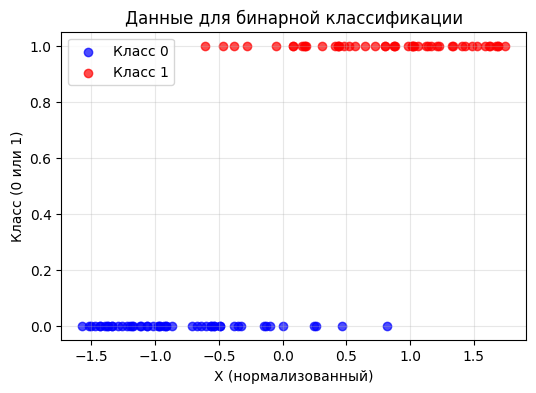

Начальный вес (w): 0.0013
Начальное смещение (b): 0.0000
w.shape: (1, 1), b.shape: (1, 1)

Начинаем обучение логистической регрессии...
---
Эпоха    0 | Loss: 0.692622 | w=0.2031 | b=0.0000
Эпоха  200 | Loss: 0.247903 | w=3.4521 | b=0.1124
Эпоха  400 | Loss: 0.247580 | w=3.6059 | b=0.1230
Эпоха  600 | Loss: 0.247574 | w=3.6266 | b=0.1244
Эпоха  800 | Loss: 0.247574 | w=3.6296 | b=0.1245
Эпоха 1000 | Loss: 0.247574 | w=3.6300 | b=0.1246
Эпоха 1200 | Loss: 0.247574 | w=3.6301 | b=0.1246
Эпоха 1400 | Loss: 0.247574 | w=3.6301 | b=0.1246
Эпоха 1600 | Loss: 0.247574 | w=3.6301 | b=0.1246
Эпоха 1800 | Loss: 0.247574 | w=3.6301 | b=0.1246
---
ИТОГИ обучения:
Финальный вес (w): 3.6301
Финальное смещение (b): 0.1246


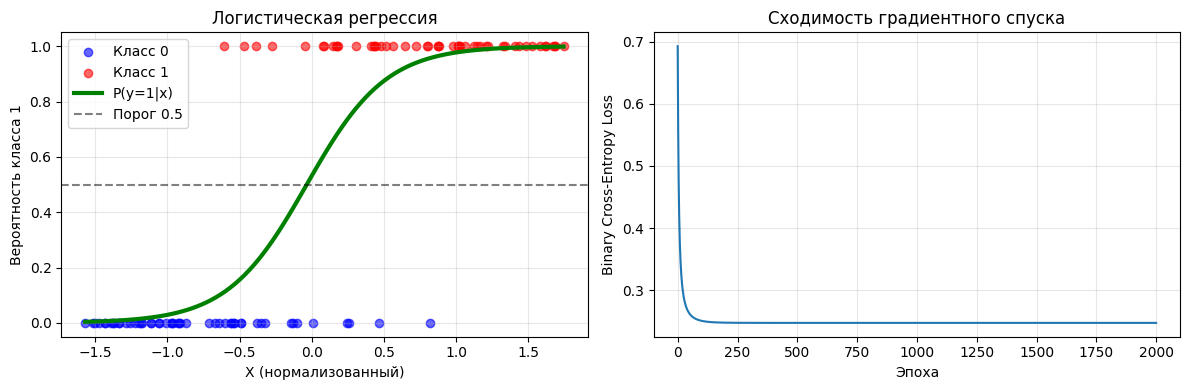


ДИАГНОСТИКА МОДЕЛИ
Shape of X: (100, 1)
Shape of y: (100, 1)
Shape of w: (1, 1)
Shape of b: (1, 1)
Shape of y_pred_prob: (100, 1)
Shape of y_pred_class: (100, 1)

Средняя предсказанная вероятность: 0.5000
Минимальная вероятность: 0.0038
Максимальная вероятность: 0.9984
Количество предсказаний класса 1: 50
Количество предсказаний класса 0: 50
Реальное количество класса 1: 50.0
Реальное количество класса 0: 50.0

✅ ТОЧНОСТЬ МОДЕЛИ: 90.00%

Корреляция X и y: 0.8080


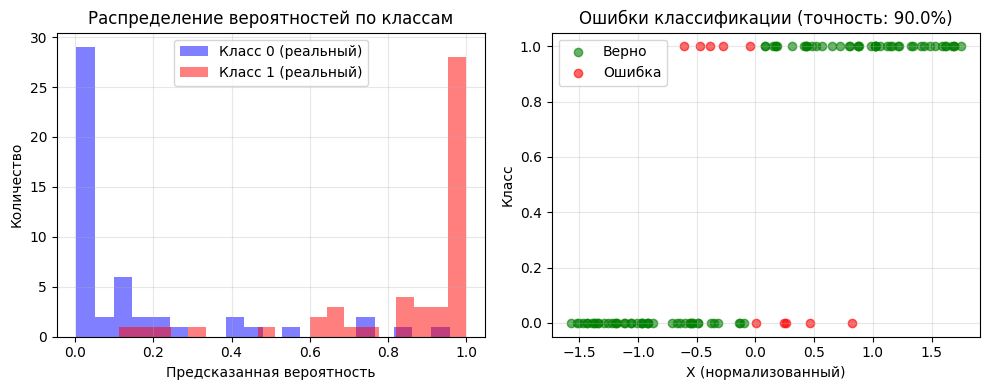


Начальный Loss: 0.692622
Конечный Loss: 0.247574
Уменьшение Loss: 64.3%


In [3]:
# %%
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Генерация данных
m = 100
X = np.random.rand(m, 1) * 10

noise = np.random.randn(m, 1) * 1.5
threshold = 5 + noise
y = (X > threshold).astype(float)

# Нормализация
X_mean = X.mean()
X_std = X.std()
X = (X - X_mean) / X_std

print(f"X диапазон: [{X.min():.2f}, {X.max():.2f}]")
print(f"Класс 0: {np.sum(y == 0)}, Класс 1: {np.sum(y == 1)}")

# Визуализация данных
plt.figure(figsize=(6, 4))
plt.scatter(X[y.flatten() == 0], y[y.flatten() == 0], color='blue', alpha=0.7, label='Класс 0')
plt.scatter(X[y.flatten() == 1], y[y.flatten() == 1], color='red', alpha=0.7, label='Класс 1')
plt.xlabel("X (нормализованный)")
plt.ylabel("Класс (0 или 1)")
plt.title("Данные для бинарной классификации")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Инициализация (улучшенная)
w = np.random.randn(1, 1) * 0.1  # Явно делаем (1, 1)
b = np.zeros((1, 1))  # Явно делаем (1, 1)

print(f"Начальный вес (w): {w[0, 0]:.4f}")
print(f"Начальное смещение (b): {b[0, 0]:.4f}")
print(f"w.shape: {w.shape}, b.shape: {b.shape}")

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y_pred_prob, y_true):
    m = y_true.shape[0]
    epsilon = 1e-15
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)
    loss = -(1 / m) * np.sum(
        y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob)
    )
    return loss

def train_step(X, y, w, b, learning_rate=0.5):
    m = X.shape[0]
    z = np.dot(X, w) + b
    y_pred_prob = sigmoid(z)
    loss = compute_loss(y_pred_prob, y)
    dz = y_pred_prob - y
    dw = (1 / m) * np.dot(X.T, dz)
    db = (1 / m) * np.sum(dz, keepdims=True)  # Сохраняем размерность
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b, loss

# Обучение
learning_rate = 0.5
epochs = 2000
loss_history = []

print("\nНачинаем обучение логистической регрессии...")
print("---")
for epoch in range(epochs):
    w, b, loss = train_step(X, y, w, b, learning_rate)
    loss_history.append(loss)
    if epoch % 200 == 0:
        # ✅ Используем правильную индексацию для (1, 1) массивов
        print(f"Эпоха {epoch:4d} | Loss: {loss:.6f} | w={w[0, 0]:.4f} | b={b[0, 0]:.4f}")

print("---")
print(f"ИТОГИ обучения:")
print(f"Финальный вес (w): {w[0, 0]:.4f}")
print(f"Финальное смещение (b): {b[0, 0]:.4f}")

# Визуализация результатов
plt.figure(figsize=(12, 4))

# График 1: Данные и разделяющая линия
plt.subplot(1, 2, 1)
plt.scatter(X[y.flatten() == 0], y[y.flatten() == 0], color='blue', alpha=0.6, label='Класс 0')
plt.scatter(X[y.flatten() == 1], y[y.flatten() == 1], color='red', alpha=0.6, label='Класс 1')

# Используем диапазон нормализованных данных
x_line = np.linspace(X.min(), X.max(), 100)
z_line = w[0, 0] * x_line + b[0, 0]
y_prob_line = sigmoid(z_line)

plt.plot(x_line, y_prob_line, color='green', linewidth=3, label='P(y=1|x)')
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Порог 0.5')

plt.xlabel("X (нормализованный)")
plt.ylabel("Вероятность класса 1")
plt.legend()
plt.title("Логистическая регрессия")
plt.grid(True, alpha=0.3)

# График 2: Сходимость Loss
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Сходимость градиентного спуска")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Предсказания и точность
y_pred_prob = sigmoid(np.dot(X, w) + b)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Диагностика
print("\n" + "="*50)
print("ДИАГНОСТИКА МОДЕЛИ")
print("="*50)
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Shape of w: {w.shape}")
print(f"Shape of b: {b.shape}")
print(f"Shape of y_pred_prob: {y_pred_prob.shape}")
print(f"Shape of y_pred_class: {y_pred_class.shape}")

# Проверяем формы
if y_pred_class.shape != y.shape:
    print(f"\n⚠️  Формы не совпадают. Исправляем...")
    y_pred_class = y_pred_class.reshape(-1, 1)

# Точность
accuracy = np.mean(y_pred_class == y) * 100

print(f"\nСредняя предсказанная вероятность: {y_pred_prob.mean():.4f}")
print(f"Минимальная вероятность: {y_pred_prob.min():.4f}")
print(f"Максимальная вероятность: {y_pred_prob.max():.4f}")
print(f"Количество предсказаний класса 1: {np.sum(y_pred_class)}")
print(f"Количество предсказаний класса 0: {len(y_pred_class) - np.sum(y_pred_class)}")
print(f"Реальное количество класса 1: {np.sum(y)}")
print(f"Реальное количество класса 0: {len(y) - np.sum(y)}")
print(f"\n✅ ТОЧНОСТЬ МОДЕЛИ: {accuracy:.2f}%")

# Проверка корреляции
print(f"\nКорреляция X и y: {np.corrcoef(X.flatten(), y.flatten())[0,1]:.4f}")

# Дополнительная диагностика: распределение вероятностей
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y_pred_prob[y.flatten() == 0], bins=20, alpha=0.5, label='Класс 0 (реальный)', color='blue')
plt.hist(y_pred_prob[y.flatten() == 1], bins=20, alpha=0.5, label='Класс 1 (реальный)', color='red')
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Количество")
plt.legend()
plt.title("Распределение вероятностей по классам")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Проверка, хорошо ли разделяются классы
correct_pred = (y_pred_class == y).flatten()
plt.scatter(X[correct_pred], y[correct_pred], color='green', alpha=0.6, label='Верно')
plt.scatter(X[~correct_pred], y[~correct_pred], color='red', alpha=0.6, label='Ошибка')
plt.xlabel("X (нормализованный)")
plt.ylabel("Класс")
plt.legend()
plt.title(f"Ошибки классификации (точность: {accuracy:.1f}%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Проверка, как изменился Loss
print(f"\nНачальный Loss: {loss_history[0]:.6f}")
print(f"Конечный Loss: {loss_history[-1]:.6f}")
print(f"Уменьшение Loss: {((loss_history[0] - loss_history[-1]) / loss_history[0] * 100):.1f}%")

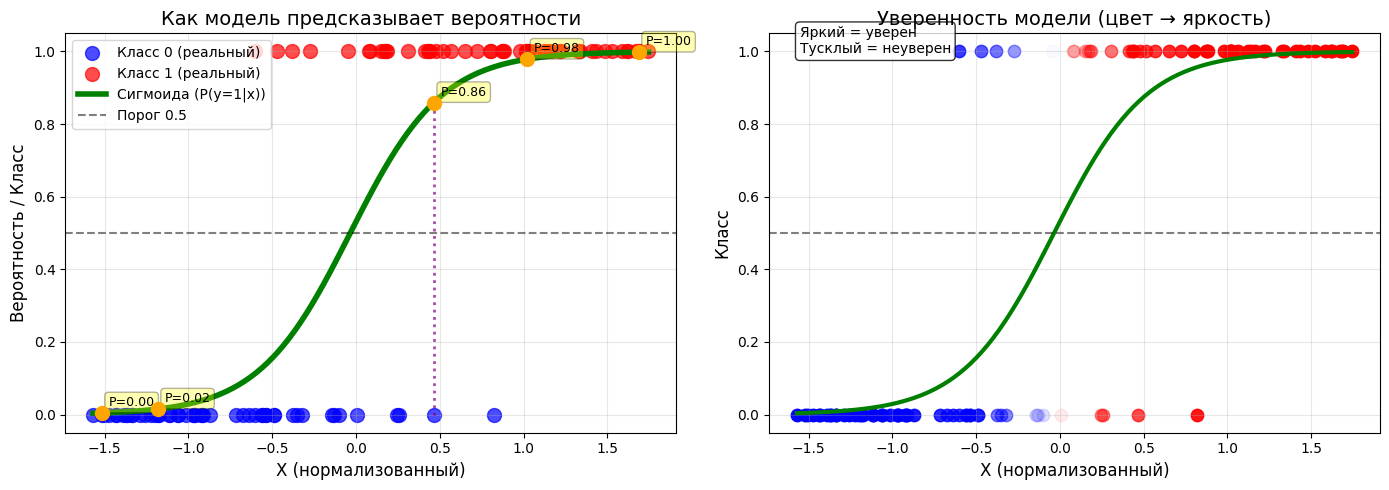

In [5]:
# Давайте создадим наглядную визуализацию
import numpy as np
import matplotlib.pyplot as plt

# Возьмём наши данные (из вашего обучения)
# X - нормализованные данные, y - метки классов

# Создаём рисунок с пояснениями
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Оригинальный график с пояснениями
ax1 = axes[0]
ax1.scatter(X[y.flatten() == 0], y[y.flatten() == 0], 
            color='blue', alpha=0.7, s=100, label='Класс 0 (реальный)')
ax1.scatter(X[y.flatten() == 1], y[y.flatten() == 1], 
            color='red', alpha=0.7, s=100, label='Класс 1 (реальный)')

# Сигмоида
x_line = np.linspace(X.min(), X.max(), 100)
z_line = w[0, 0] * x_line + b[0, 0]
y_prob_line = sigmoid(z_line)
ax1.plot(x_line, y_prob_line, color='green', linewidth=4, label='Сигмоида (P(y=1|x))')
ax1.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Порог 0.5')

# Добавляем вертикальные линии для нескольких точек
sample_indices = [10, 30, 50, 70, 90]
for idx in sample_indices:
    x_val = X[idx, 0]
    y_true = y[idx, 0]
    y_pred_prob = sigmoid(w[0, 0] * x_val + b[0, 0])
    
    # Вертикальная линия от точки до кривой
    ax1.plot([x_val, x_val], [y_true, y_pred_prob], 
             color='purple', linestyle=':', linewidth=2, alpha=0.7)
    
    # Точка на кривой
    ax1.scatter(x_val, y_pred_prob, color='orange', s=100, zorder=5)
    
    # Подпись
    ax1.annotate(f'P={y_pred_prob:.2f}', 
                xy=(x_val, y_pred_prob), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax1.set_xlabel("X (нормализованный)", fontsize=12)
ax1.set_ylabel("Вероятность / Класс", fontsize=12)
ax1.set_title("Как модель предсказывает вероятности", fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# График 2: "Уверенность" модели
ax2 = axes[1]

# Для каждой точки показываем уверенность модели
for idx in range(len(X)):
    x_val = X[idx, 0]
    y_true = y[idx, 0]
    y_pred_prob = sigmoid(w[0, 0] * x_val + b[0, 0])
    
    # Цвет зависит от уверенности
    if y_true == 0:
        color = 'blue'
        if y_pred_prob > 0.5:
            color = 'red'  # Ошибка
        alpha = abs(y_pred_prob - 0.5) * 2  # Уверенность
    else:
        color = 'red'
        if y_pred_prob < 0.5:
            color = 'blue'  # Ошибка
        alpha = abs(y_pred_prob - 0.5) * 2
    
    ax2.scatter(x_val, y_true, color=color, alpha=alpha, s=80)

# Добавляем сигмоиду
ax2.plot(x_line, y_prob_line, color='green', linewidth=3, label='Сигмоида')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

ax2.set_xlabel("X (нормализованный)", fontsize=12)
ax2.set_ylabel("Класс", fontsize=12)
ax2.set_title("Уверенность модели (цвет → яркость)", fontsize=14)
ax2.text(0.05, 0.95, "Яркий = уверен\nТусклый = неуверен", 
         transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()